In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

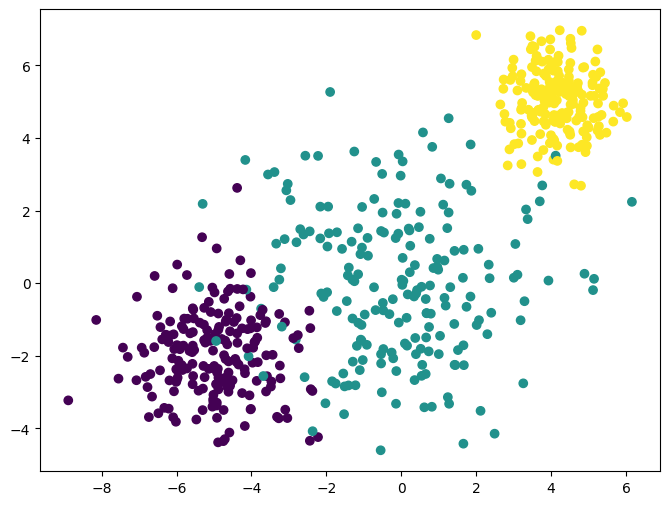

In [21]:
# Loading dataset
X,y = make_blobs(
    n_samples=600,
    centers=[[-5,-2],[0,0],[4,5]],
    cluster_std=[1.2,2.0,0.8],
    random_state=42
)
plt.figure(figsize=(8,6))
plt.scatter(X[:,0],X[:,1],c=y)

In [18]:
class GMM:
    def __init__(self,k=3,iters=1000):
        self.k = k
        self.iters = iters
        
        self.mu = None
        self.sigma = None
    
    def gaussian(self,X,mu,sigma):
        m,n = X.shape
        sigma = sigma+np.eye(n)*1e-6
        
        det = np.linalg.det(sigma)
        inv = np.linalg.inv(sigma)
        diff = X-mu
        pow = -0.5*(np.sum((diff@inv)*diff,axis=1))
        pre = 1/np.sqrt(((2*np.pi)**n)*det)
        return (pre*np.exp(pow))
    
    def fit(self,X):
        m,n = X.shape
        # Randomly initialise k gaussians
        indices = np.random.choice(m,self.k,replace=False)
        self.mu = X[indices]
        self.sigma = [np.eye(n) for _ in range(self.k)]
        
        prob = np.zeros((m,self.k))
        for _ in range(self.iters):
            # E Step
            for i in range(self.k):
                prob[:,i]=self.gaussian(X,self.mu[i],self.sigma[i])
            prob/=prob.sum(axis=1,keepdims=True)
            tot = prob.sum(axis=0)
            # M Step
            for i in range(self.k):
                weights = prob[:,i]
                weighted_X = X*weights.reshape(-1,1)
                self.mu[i] = weighted_X.sum(axis=0)/tot[i]
                
                diff = X-self.mu[i]
                weighted_diff = diff*weights.reshape(-1,1)
                self.sigma[i]=(weighted_diff.T@diff)/tot[i]
    
    def predict(self,X):
        m,n = X.shape
        probs = np.zeros((m,self.k))
        for k in range(self.k):
            probs[:,k]=self.gaussian(X,self.mu[k],self.sigma[k])
        return np.argmax(probs,axis=1)

In [19]:
model = GMM(k=3)
model.fit(X)
labels = model.predict(X)

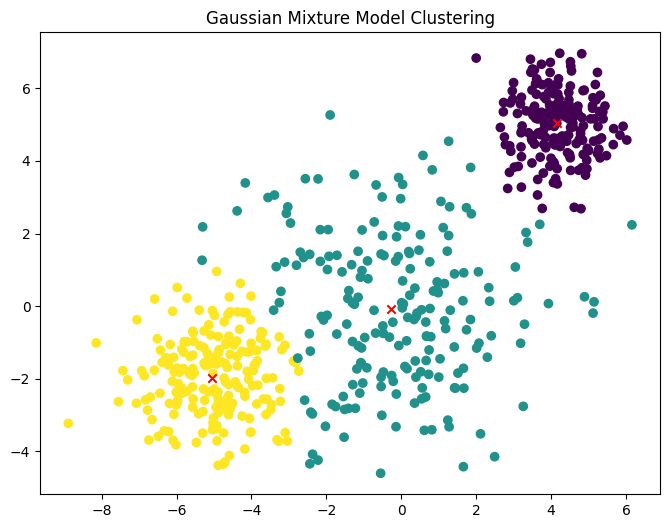

In [20]:
plt.figure(figsize=(8,6))
plt.scatter(X[:,0],X[:,1],c=labels)
plt.scatter(model.mu[:,0],model.mu[:,1],c='red',marker='x')
plt.title("Gaussian Mixture Model Clustering")
plt.show()